In [106]:
import pandas as pd
import numpy as np
from numpy import random
import matplotlib.pyplot as plt
import seaborn as sns


In [107]:
file_path="/Users/tejasmac/Downloads/netflix_titles.csv"
df=pd.read_csv(file_path,index_col="show_id")

In [ ]:
print(df)

In [ ]:
print(df.dtypes)
print(df.shape)

In [90]:
print(list(df.columns))

['type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [ ]:
print(df.isnull().sum())

In [ ]:
plt.figure(figsize=(7,3))
year_type=df.groupby(["type","release_year"]).size().reset_index(name="count")

sns.lineplot(x="release_year",y="count",data=year_type,hue="type")
plt.legend(title="Legend")
plt.xlabel("Release Year")
plt.ylabel("Movie / TV Show Released")
plt.title("Netflix Data")





Index(['listed_in', 'count'], dtype='str')
<class 'pandas.DataFrame'>


<Axes: title={'center': 'Top 10 Genres of Netflix'}, xlabel='Genres', ylabel='Movies/Shows produced'>

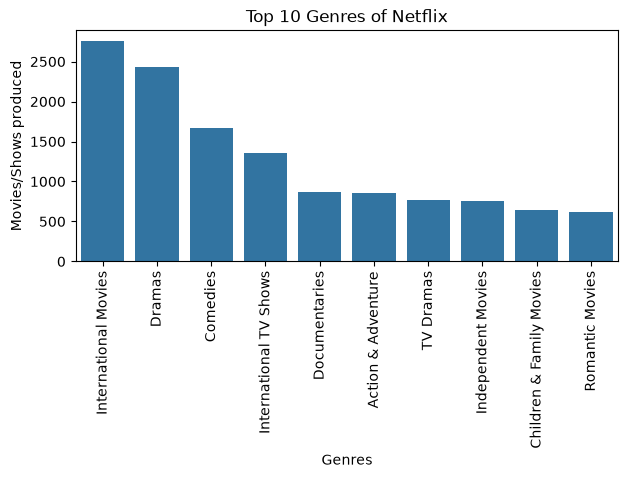

In [ ]:
genre=df["listed_in"].str.split(", ").explode().value_counts().head(10).reset_index(name="count")
print(genre.columns)

plt.figure(figsize=(7,3))
plt.xticks(rotation=90)
plt.ylabel("Movies/Shows produced")
plt.xlabel("Genres")
plt.title("Top 10 Genres of Netflix")
sns.barplot(x="listed_in",y="count",data=genre)



<Axes: title={'center': 'Top 15 Directors'}, xlabel='Directors', ylabel='Avg. Movies produced'>

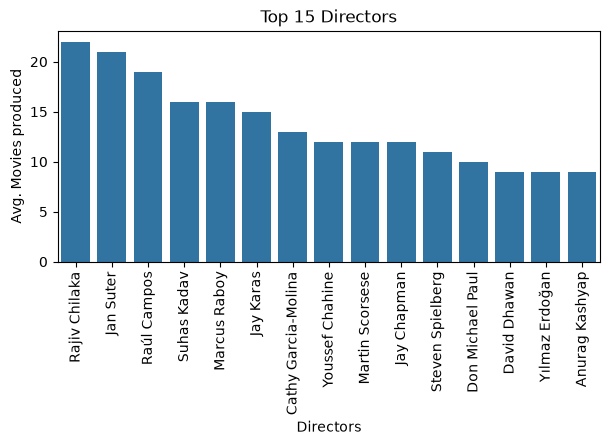

In [103]:
#top15_directors=df.groupby("director")["title"].size().sort_values(ascending=False).head(15).reset_index(name="counts")

top15_directors=df["director"].dropna().str.split(", ").explode().value_counts().head(15).reset_index(name="counts")

plt.figure(figsize=(7,3))
plt.xticks(rotation=90)
plt.xlabel("Directors")
plt.ylabel("Avg. Movies produced")
plt.title("Top 15 Directors")
sns.barplot(x="director",y="counts",data=top15_directors)


/var/folders/z7/_gn2bbvd0qb718ymxj6z82j00000gn/T/ipykernel_97305/3848253342.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="cast",y="count",data=top15_actors,palette="viridis")


<Axes: xlabel='Actors', ylabel='No. of Movies'>

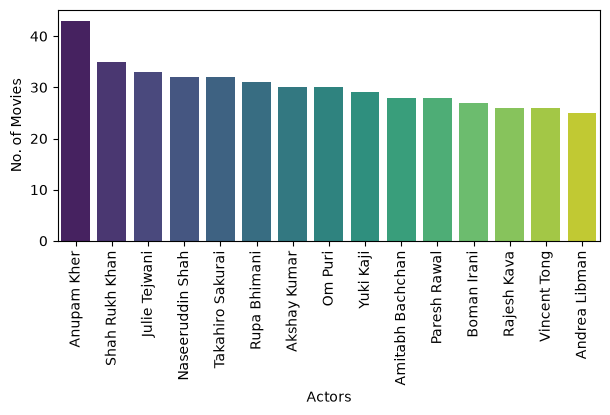

In [120]:
top15_actors=df["cast"].dropna().str.split(", ").explode().value_counts().head(15).reset_index(name="count")

plt.figure(figsize=(7,3))
plt.tight_layout()
plt.xticks(rotation=90)
plt.xlabel("Actors")
plt.ylabel("No. of Movies")

sns.barplot(x="cast",y="count",data=top15_actors,palette="viridis")

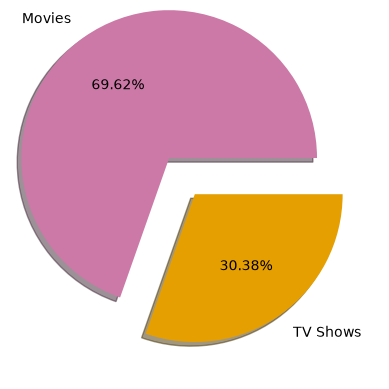

In [136]:
Colors=["#CC79A7","#E69F00"]
plt.pie(df["type"].value_counts(),labels=["Movies","TV Shows"],autopct="%.2f%%",shadow=True,explode=[.3,0],labeldistance=1.15,colors=Colors)

<Axes: xlabel='Duration in mins', ylabel='No. of Movies'>

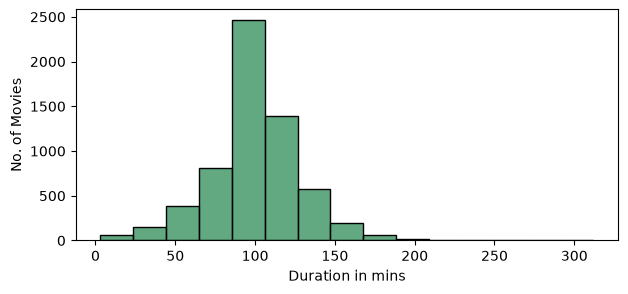

In [144]:
movies=df[df["type"]=="Movie"]
movies_duration=movies["duration"].str.replace(" min","")
movies_duration=pd.to_numeric(movies_duration)

plt.figure(figsize=(7,3))

plt.xlabel("Duration in mins")
plt.ylabel("No. of Movies")

sns.histplot(movies_duration,bins=15,color="seagreen")

<Axes: xlabel='Release Year', ylabel='Duration in mins'>

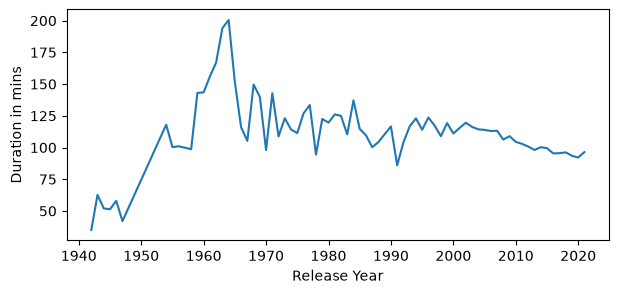

In [157]:
movies=df[df["type"]=="Movie"].copy()
movies["duration"]=pd.to_numeric(movies["duration"].str.replace(" min",""))


grp_movies=movies.groupby("release_year")["duration"].mean().reset_index(name="Duration in mins")

plt.figure(figsize=(7,3))
plt.xlabel("Release Year")

sns.lineplot(x="release_year",y="Duration in mins",data=grp_movies)

<Axes: xlabel='rating', ylabel='Total Ratings'>

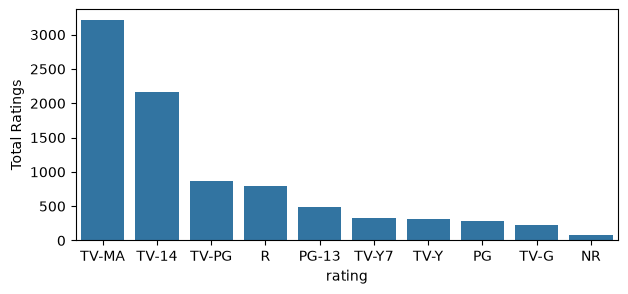

In [160]:
ratings=df["rating"].value_counts().head(10).reset_index(name="Total Ratings")
plt.figure(figsize=(7,3))

sns.barplot(x="rating",y="Total Ratings",data=ratings)

<Axes: title={'center': 'Top 10 Countries'}, xlabel='Countries', ylabel='No. of Movies/Shows'>

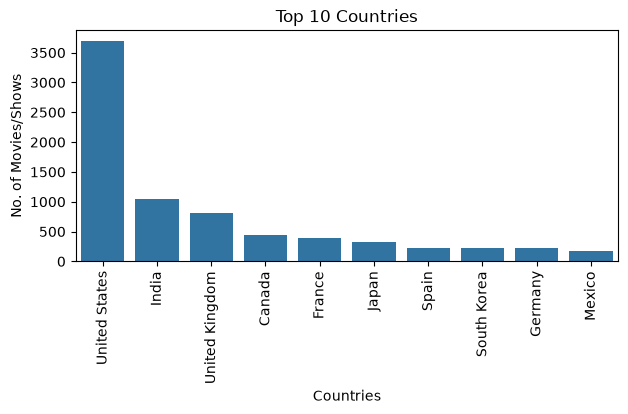

In [176]:
countries=df.copy()

countries["country"]=countries["country"].str.split(", ")
countries=countries.explode("country")

top10_countries=countries.groupby("country")["type"].size().reset_index(name="count").sort_values(by="count",ascending=False).head(10)


plt.figure(figsize=(7,3))
plt.xticks(rotation=90)
plt.xlabel("Countries")
plt.ylabel("No. of Movies/Shows")
plt.title("Top 10 Countries")
sns.barplot(x="country",y="count",data=top10_countries)

<Axes: title={'center': 'Content Added to Netflix by Month'}, xlabel='Months', ylabel='No. of Titles'>

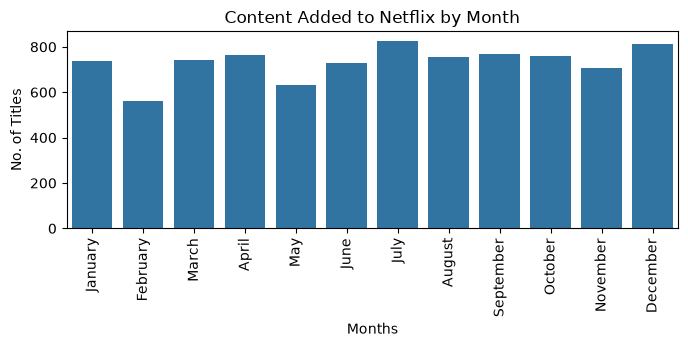

In [189]:
month_df=df.copy()

month_df["date_added"]=month_df["date_added"].str.strip()

month_df["date_added"]=pd.to_datetime(month_df["date_added"])

month_df["month_num"]=month_df["date_added"].dt.month
month_df["month"]=month_df["date_added"].dt.month_name()

release_by_month=month_df.groupby(["month_num","month"])["title"].size().reset_index(name="count").sort_values(by="month_num")


plt.figure(figsize=(7,3))
plt.xticks(rotation=90)
plt.ylabel("No. of Titles")
plt.xlabel("Months")
plt.title("Content Added to Netflix by Month")
plt.tight_layout()
sns.barplot(x="month",y="count",data=release_by_month)


<Axes: xlabel='type', ylabel='rating'>

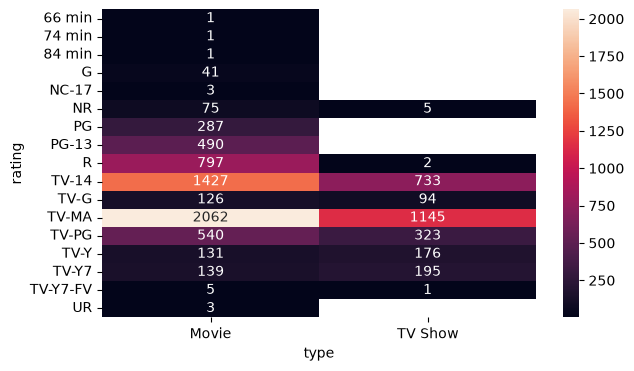

In [207]:
pivot=df.pivot_table(index="rating",columns="type",values="title",aggfunc="count")


plt.figure(figsize=(7,4))
plt.tight_layout()
sns.heatmap(data=pivot,annot=True,fmt=".0f")


Text(0.5, 1.0, 'Comparison between Movies and Shows added by top 5 countries on Netflix')

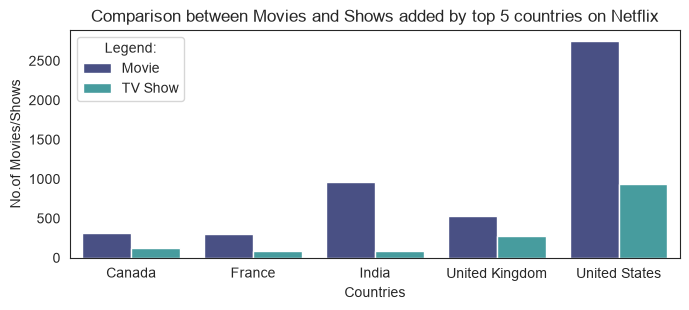

In [272]:
movies=df.copy()

movies=movies[movies["type"]=="Movie"]

movies["country"]=movies["country"].str.split(", ")
movies=movies.explode("country")

top_5_movies=movies.groupby("country")["title"].size().reset_index(name="count").sort_values(by="count",ascending=False).head(5)

country_type=df.copy()

country_type["country"]=country_type["country"].str.split(", ")
country_type=country_type.explode("country")

country_type=country_type[country_type["country"].isin(top_5_movies["country"])]

comparison=country_type.groupby(["country","type"]).size().reset_index(name="count")



plt.figure(figsize=(7,3))
sns.set_style("white")

sns.barplot(x="country",y="count",hue="type",data=comparison,palette="mako")

plt.tight_layout()
plt.xlabel("Countries")
plt.ylabel("No.of Movies/Shows")
plt.legend(title="Legend:")
plt.title("Comparison between Movies and Shows added by top 5 countries on Netflix")



Text(0.5, 1.0, 'Top 10 years with the highest number of releases on Netflix ')

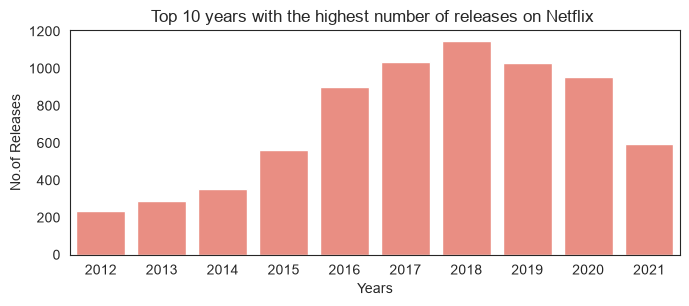

In [285]:
top_10_years=df.groupby("release_year")["title"].size().reset_index(name="count").sort_values(by="count",ascending=False).head(10)


plt.figure(figsize=(7,3))

sns.barplot(x="release_year",y="count",data=top_10_years,color="salmon")

plt.tight_layout()
plt.xlabel("Years")
plt.ylabel("No.of Releases")
plt.title("Top 10 years with the highest number of releases on Netflix ")

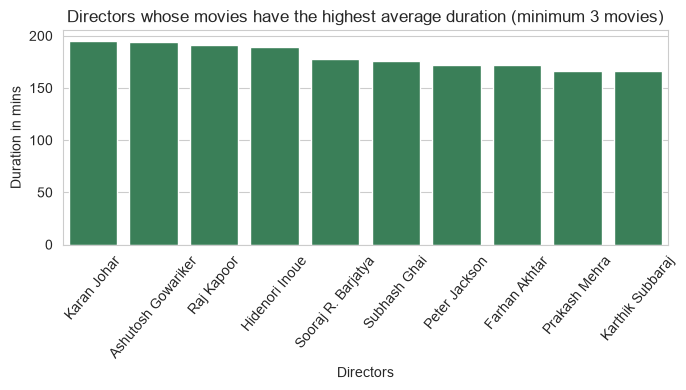

In [310]:
directors=df.copy()

directors=directors[directors["type"]=="Movie"]
top_directors=directors.groupby("director")["title"].size().reset_index(name="count").sort_values(by="count",ascending=False)
top_directors=top_directors[top_directors["count"]>=3]



movies=df.copy()

movies=movies[movies["type"]=="Movie"]
movies["duration"]=movies["duration"].str.replace(" min","")
movies["duration"]=pd.to_numeric(movies["duration"])
movies=movies[movies["director"].isin(top_directors["director"])]

comparison=movies.groupby("director")["duration"].mean().reset_index(name="count").sort_values(by="count",ascending=False).head(10)



plt.figure(figsize=(7,4))
sns.barplot(x="director",y="count",data=comparison,color="seagreen")
sns.set_style("whitegrid")

plt.xlabel("Directors")
plt.ylabel("Duration in mins")
plt.xticks(rotation=50)
plt.title("Directors whose movies have the highest average duration (minimum 3 movies)")
plt.tight_layout()



Text(0.5, 1.0, 'The percentage contribution of the top 10 genres to the entire catalog of Netflix')

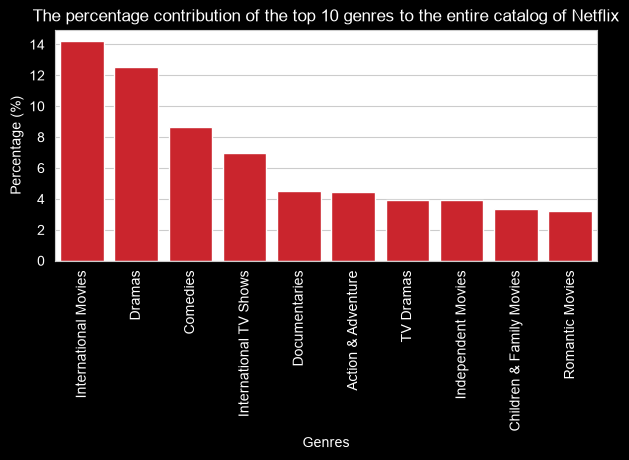

In [401]:
genre=df.copy()
genre["listed_in"]=genre["listed_in"].str.split(", ")
genre=genre.explode("listed_in")
total=genre.shape[0]

comparison=genre.groupby("listed_in")["title"].size().reset_index(name="count").sort_values(by="count",ascending=False).head(10)
total=genre.shape[0]
comparison["percentage"]=comparison["count"]/total*100


plt.figure(figsize=(7,3),facecolor="#000000")

plt.xticks(rotation=90,color="#FFFFFF")
plt.yticks(color="#FFFFFF")
sns.set_style("whitegrid")
sns.barplot(x="listed_in",y="percentage",data=comparison,color="#E50914")
plt.xlabel("Genres",color="#FFFFFF")
plt.ylabel("Percentage (%)",color="#FFFFFF")
plt.title("The percentage contribution of the top 10 genres to the entire catalog of Netflix",color="#FFFFFF")


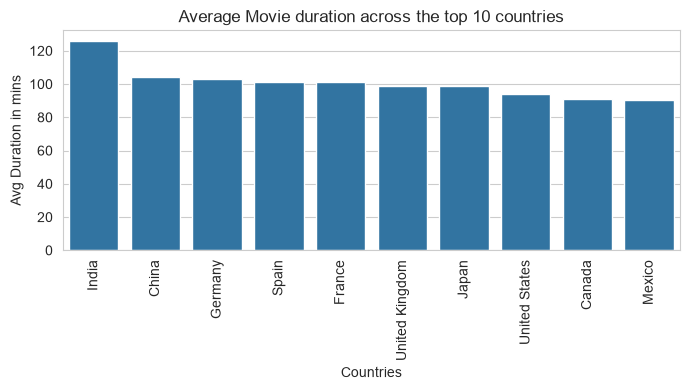

In [ ]:
countries_movie=df.copy()

countries_movie=countries_movie[countries_movie["type"]=="Movie"]
countries_movie["duration"]=countries_movie["duration"].str.replace(" min","")
countries_movie["duration"]=pd.to_numeric(countries_movie["duration"])
countries_movie["country"]=countries_movie["country"].str.split(", ")
countries_movie=countries_movie.explode("country")

countries=df.copy()

countries=countries[countries["type"]=="Movie"]

countries["country"]=countries["country"].str.split(", ")
countries=countries.explode("country")

top_10_countries=countries.groupby("country")["title"].size().reset_index(name="count").sort_values(by="count",ascending=False).head(10)


countries_movie=countries_movie[countries_movie["country"].isin(top_10_countries["country"])]

comparison=countries_movie.groupby("country")["duration"].mean().reset_index(name="avg_duration").sort_values(by="avg_duration",ascending=False)




plt.figure(figsize=(7,4))
sns.barplot(x="country",y="avg_duration",data=comparison)

plt.xlabel("Countries")
plt.ylabel("Avg Duration in mins")
plt.title("Average Movie duration across the top 10 countries")
plt.xticks(rotation=90)
plt.tight_layout()



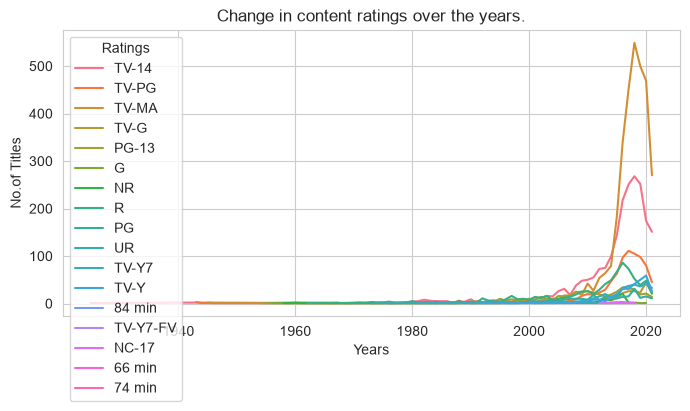

In [424]:
ratings=df.copy()

ratings_over_years=ratings.groupby(["rating","release_year"]).size().reset_index(name="count").sort_values(by="release_year",ascending=True)


plt.figure(figsize=(7,4))
sns.lineplot(x="release_year",y="count",hue="rating",data=ratings_over_years)
plt.xlabel("Years")
plt.ylabel("No.of Titles")
plt.title("Change in content ratings over the years.")
plt.legend(title="Ratings")
plt.tight_layout()

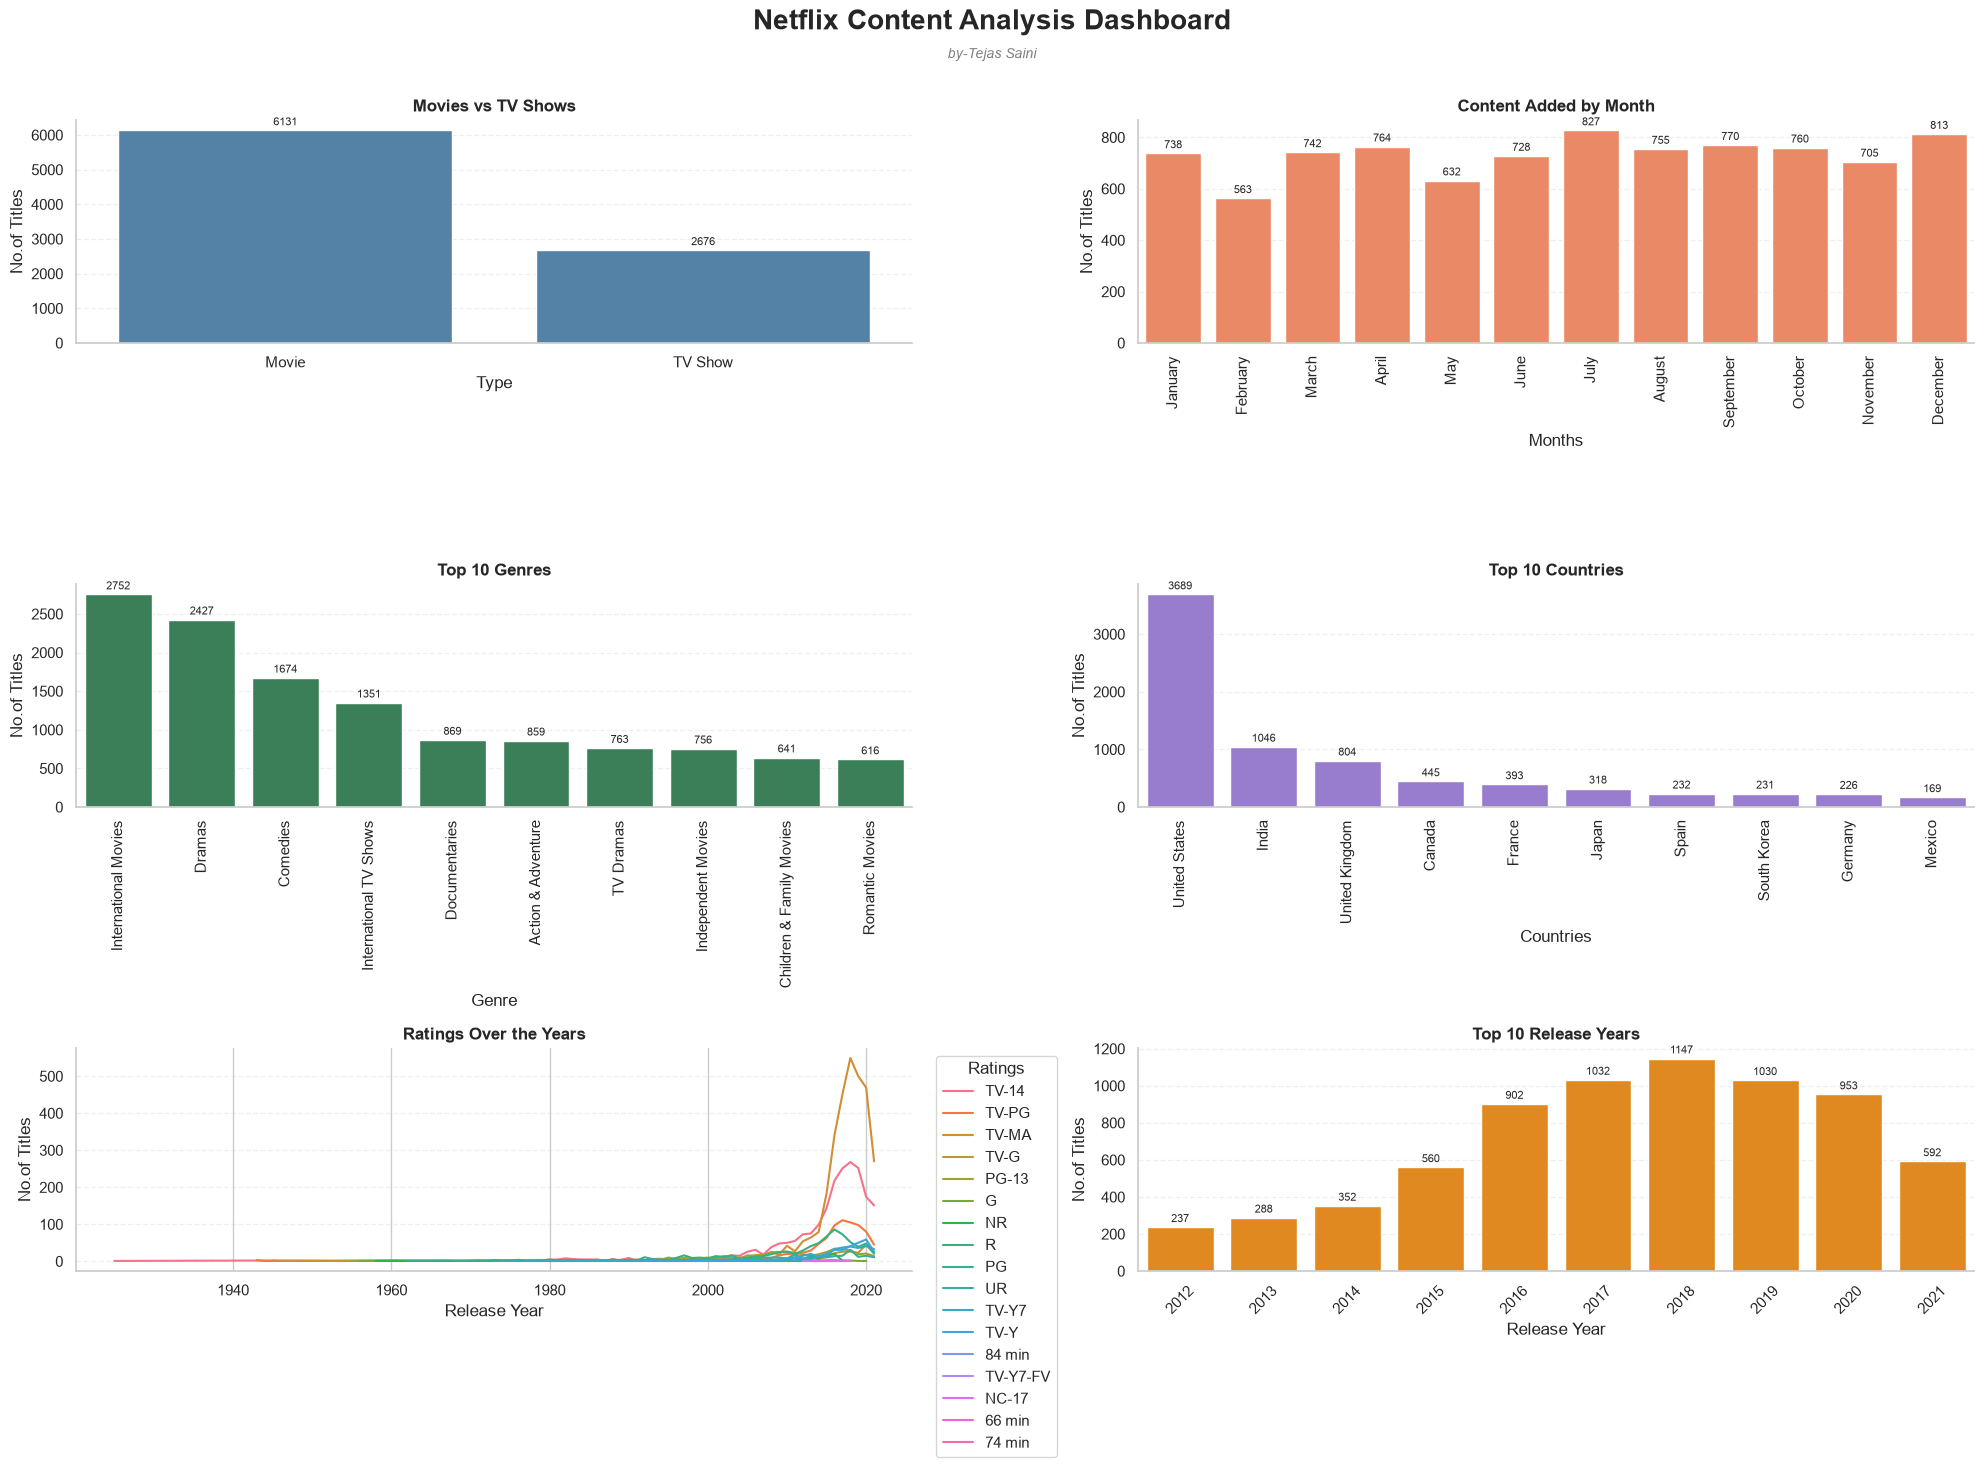

In [541]:
figure,axes=plt.subplots(3,2,figsize=(20,14))

content_by_month=df.copy()
content_by_month["date_added"]=content_by_month["date_added"].str.strip()
content_by_month["date_added"]=pd.to_datetime(content_by_month["date_added"])
content_by_month["month_num"]=content_by_month["date_added"].dt.month
content_by_month["month"]=content_by_month["date_added"].dt.month_name()
release_by_month=content_by_month.groupby(["month","month_num"])["title"].size().reset_index(name="count").sort_values(by="month_num")


type_count=df["type"].value_counts().reset_index()
type_count.columns=["type","count"]


genres=df.copy()
genres["listed_in"]=genres["listed_in"].str.split(", ")
genres=genres.explode("listed_in")
top_genres=genres.groupby("listed_in")["title"].size().reset_index(name="count").sort_values(by="count",ascending=False).head(10)


countries=df.copy()
countries["country"]=countries["country"].str.split(", ")
countries=countries.explode("country")
top_countries=countries.groupby("country")["title"].size().reset_index(name="count").sort_values(by="count",ascending=False).head(10)


Rating=df.copy()
new_ratings=Rating.groupby(["rating","release_year"]).size().reset_index(name="count").sort_values(by="release_year",ascending=True)

release=df.copy()
top_release_years=release.groupby("release_year")["title"].size().reset_index(name="count").sort_values(by="count",ascending=False).head(10)



sns.barplot(x="type",y="count",data=type_count,ax=axes[0,0],color="steelblue")
sns.barplot(x="month",y="count",data=release_by_month,ax=axes[0,1],color="coral")
sns.barplot(x="listed_in",y="count",data=top_genres,ax=axes[1,0],color="seagreen")
sns.barplot(x="country",y="count",data=top_countries,ax=axes[1,1],color="mediumpurple")
sns.lineplot(x="release_year",y="count",hue="rating",data=new_ratings,ax=axes[2,0])
sns.barplot(x="release_year",y="count",data=top_release_years,ax=axes[2,1],color="darkorange")

axes[0,1].tick_params(axis="x",rotation=90)
axes[1,0].tick_params(axis="x",rotation=90)
axes[1,1].tick_params(axis="x", rotation=90)
axes[2,1].tick_params(axis="x", rotation=45)


figure.suptitle("Netflix Content Analysis Dashboard",fontsize=20,fontweight="bold")

axes[0,0].set_title("Movies vs TV Shows", fontweight="bold")
axes[0,1].set_title("Content Added by Month", fontweight="bold")
axes[1,0].set_title("Top 10 Genres", fontweight="bold")
axes[1,1].set_title("Top 10 Countries", fontweight="bold")
axes[2,0].set_title("Ratings Over the Years", fontweight="bold")
axes[2,1].set_title("Top 10 Release Years", fontweight="bold")

axes[0,0].set_xlabel("Type")
axes[0,0].set_ylabel("No.of Titles")

axes[0,1].set_xlabel("Months")
axes[0,1].set_ylabel("No.of Titles")

axes[1,0].set_xlabel("Genre")
axes[1,0].set_ylabel("No.of Titles")

axes[1,1].set_xlabel("Countries")
axes[1,1].set_ylabel("No.of Titles")

axes[2,0].set_xlabel("Release Year")
axes[2,0].set_ylabel("No.of Titles")

axes[2,1].set_xlabel("Release Year")
axes[2,1].set_ylabel("No.of Titles")


for row in axes:
    for ax in row:
        ax.grid(axis="y", linestyle="--", alpha=0.3)

for row in axes:
    for ax in row:
        sns.despine(ax=ax)

sns.set_theme(style="whitegrid")

figure.patch.set_facecolor("#ffffff")

axes[2,0].legend(
    title="Ratings",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)


figure.text(
    0.5, 0.945,
    "by-Tejas Saini",
    ha="center",
    fontsize=10,
    color="gray", fontstyle="italic"
)

bar_axes = [
    axes[0,0],
    axes[0,1],
    axes[1,0],
    axes[1,1],
    axes[2,1]
]

for ax in bar_axes:
    for container in ax.containers:
        ax.bar_label(
            container,
            fontsize=8,
            padding=2
        )

plt.tight_layout(rect=[0,0,1,.96])

plt.savefig("Netflix_Dashboard.png",dpi=300,bbox_inches="tight")
